# Spectrum class example

Minimum working example of the `Spectrum` class, including rebinning and smoothing.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from wara import spectrum as sp
from wara import file_reader

Load a calibrated CeBr3 spectrum from a CSV file.

In [2]:
file = "data/test_data_cebr_cal.csv"
df = pd.read_csv(file)

Instantiate a `Spectrum` object. Energies are optional — if omitted, channel numbers are used.

In [3]:
spect = sp.Spectrum(counts=df["counts"], energies=df["Energy [keV]"], e_units="keV")
print(spect)
print(spect.metadata())

Spectrum(label=None, channels=4096, counts=1.638E+06, livetime=N/A, calibrated=True)
{'label': None, 'description': None, 'acq_date': None, 'realtime': None, 'livetime': None, 'cps': False, 'e_units': 'keV', 'energy_cal': None, 'n_channels': 4096, 'total_counts': np.float64(1637739.0)}


Plot the original spectrum, then rebin by 2 and apply moving-average smoothing. Rebinning conserves total counts; smoothing does not.

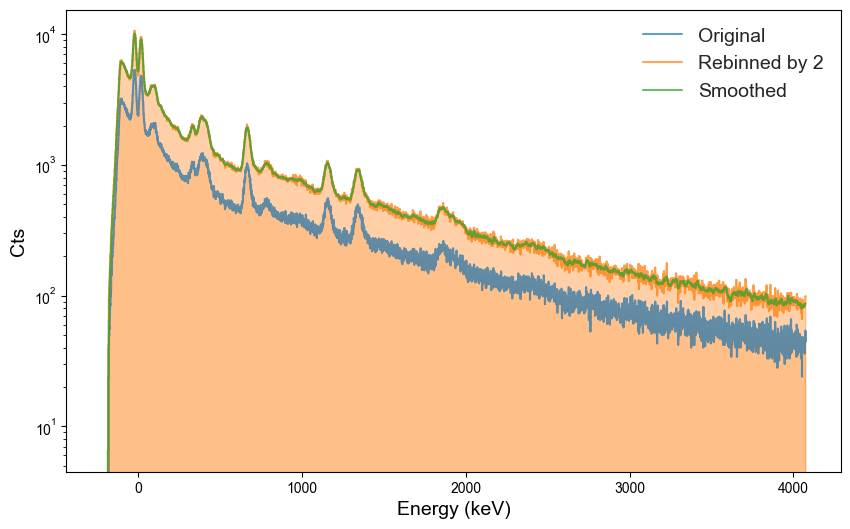

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
spect.label = "Original"
spect.plot(ax=ax)

spect.label = "Rebinned by 2"
spect.rebin(by=2)
spect.plot(ax=ax)

spect.label = "Smoothed"
spect.smooth(num=6)
spect.plot(ax=ax)
plt.show()